# lrdata to MuData

### Load packages

In [1]:
from pathlib import Path
import scanpy as sc
import squidpy as sq
import liana as li
import pandas as pd
import os

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in future Python versions; wr

## Load and Prep Data

In [2]:
# file_path = "data/MERFISH_mouse_brain/WB_MERFISH_animal2_coronal.h5ad"
# backup_url = "https://datasets.cellxgene.cziscience.com/93c3bb97-ea05-4ee0-a760-a1508cd04612.h5ad"

# if os.path.exists(file_path):
#     adata = sc.read(file_path)
# else:
#     adata = sc.read(
#     file_path,
#     backup_url=backup_url
# )

# adata = adata[adata.obs["brain_section_label"] == "C57BL6J-2.039"]
# adata.var_names = adata.var["gene_name"]
# adata.obsm['spatial'] = adata.obsm['X_spatial_coords']

In [3]:
# data_path = Path("data/agne_cd/")
# adata = sc.read_h5ad(data_path / "RUN1_SLIDE2_S6.h5ad")

# adata.obsm['spatial'] = adata.obs[['x', 'y']].to_numpy()

# adata.obs['cell_type'] = adata.obs['CellAnnotation.Level0']

In [4]:
adata = sc.read("../../data/kuppe_heart19.h5ad", backup_url='https://figshare.com/ndownloader/files/41501073?private_link=4744950f8768d5c8f68c')
adata.obs['cell_type'] = adata.obs['celltype_niche']

In [5]:
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

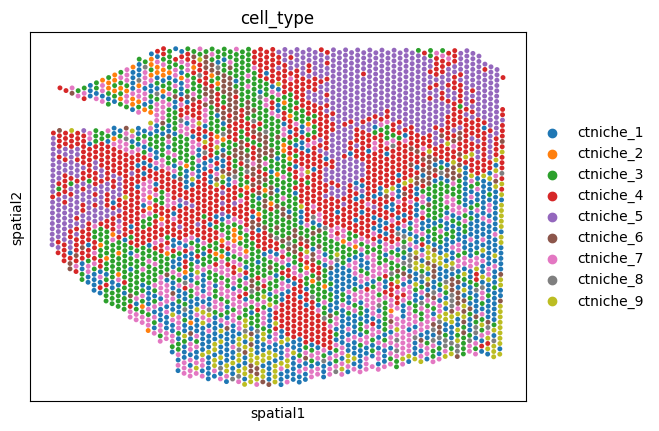

In [41]:
sc.pl.embedding(adata, basis="spatial", color=["cell_type"], wspace=0.4, s=50)

Use the chosen bandwidth based on this exploration to compute the final spatial connectivity matrix $W_{ij}$.

In [7]:
li.ut.spatial_neighbors(adata=adata, bandwidth=200)

#### Visualize proximity

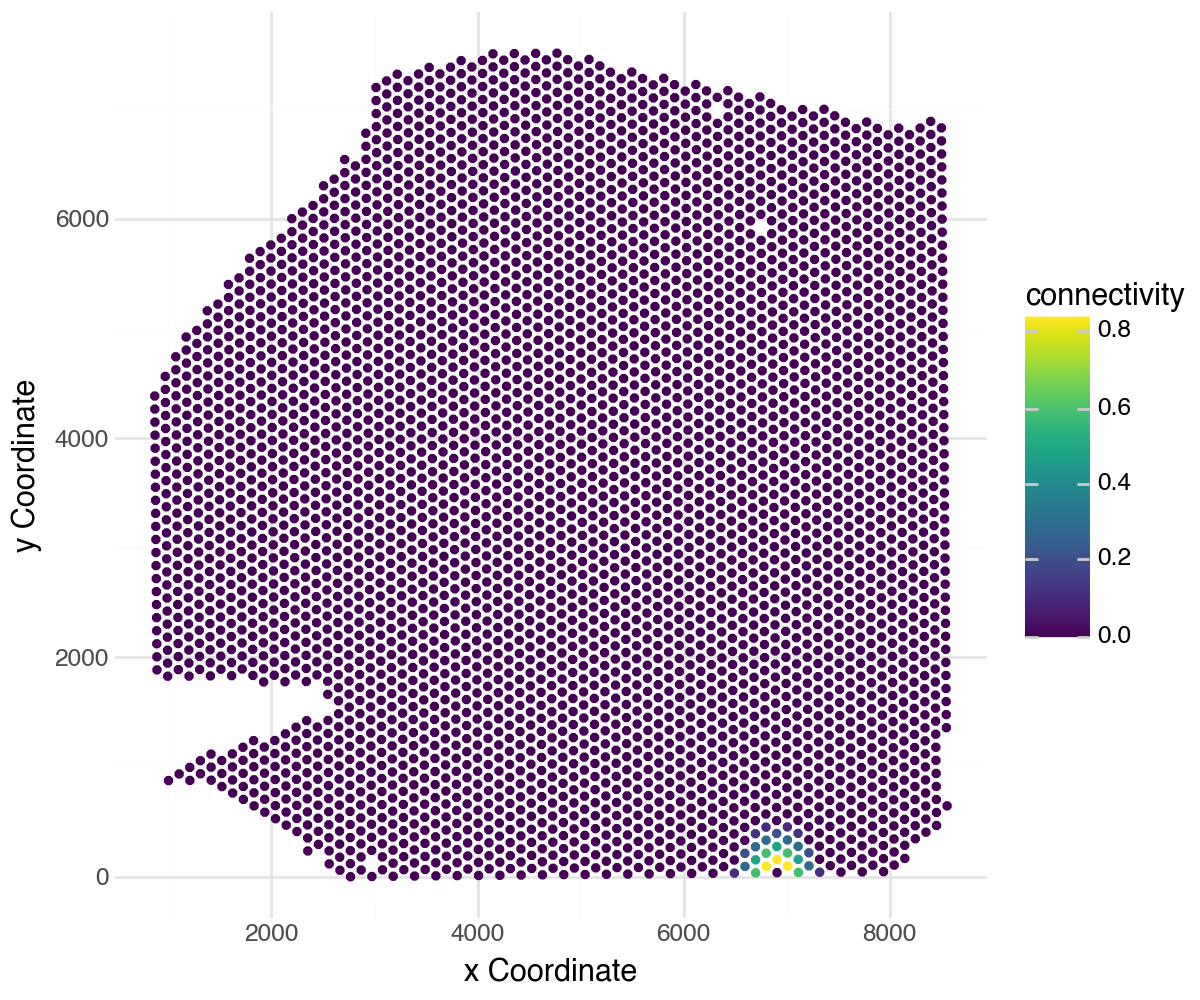

In [8]:
li.pl.connectivity(adata, idx=1000, size=1, figure_size=(6, 5))

### Find spatially variable genes (SVGs) using Morans'I

In [9]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, show_progress_bar=True)

In [10]:
adata.uns['moranI']
#I: Moran’s I score for each gene
#pval: p-value (if permutation test is used)
#var_norm: Variance used to normalize Moran’s I (used internally for significance).
#pval_norm_fdr_bh: FDR-adjusted p-value (Benjamini-Hochberg correction) for multiple testing.

,I,pval_norm,var_norm,pval_norm_fdr_bh
DES,0.769688,0.000000,0.000016,0.000000
MYL2,0.756740,0.000000,0.000016,0.000000
MYH6,0.747948,0.000000,0.000016,0.000000
TPM1,0.737534,0.000000,0.000016,0.000000
TNNC1,0.734646,0.000000,0.000016,0.000000
...,...,...,...,...
AC093297.2,-0.009878,0.007852,0.000016,0.020998
AP4M1,-0.009879,0.007845,0.000016,0.020985
AKR1E2,-0.009983,0.007299,0.000016,0.019701
WDFY2,-0.010201,0.006266,0.000016,0.017201


### Filter by spatially variable genes (SVGs)

In [11]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

6301

In [12]:
adata = adata[:, svgs]

In [13]:
# Rename to more informative names
full_names = {'Adipo': 'Adipocytes',
              'CM': 'Cardiomyocytes',
              'Endo': 'Endothelial',
              'Fib': 'Fibroblasts',
              'PC': 'Pericytes',
              'prolif': 'Proliferating',
              'vSMCs': 'Vascular_SMCs',
              }
# but only for the ones that are in the data
adata.obsm['compositions'].columns = [full_names.get(c, c) for c in adata.obsm['compositions'].columns]

In [14]:
adata.obsm['compositions'].head()

,Adipo,CM,Endo,Fib,Lymphoid,Mast,Myeloid,Neuronal,PC,prolif,vSMCs
AAACAAGTATCTCCCA-1,0.000021,1.951450e-01,0.037791,0.563484,0.008058,0.000425,0.083479,0.072724,0.006092,0.019511,0.013270
AAACAATCTACTAGCA-1,0.000012,2.041634e-06,0.098946,0.765965,0.007576,0.002032,0.078732,0.002379,0.015299,0.028458,0.000600
AAACACCAATAACTGC-1,0.000018,8.812308e-08,0.069911,0.502140,0.039207,0.075268,0.273766,0.000020,0.038670,0.000942,0.000059
AAACAGAGCGACTCCT-1,0.003114,2.159587e-01,0.213653,0.230822,0.016849,0.000168,0.099339,0.052346,0.092069,0.071544,0.004137
AAACAGCTTTCAGAAG-1,0.000298,1.267548e-05,0.076673,0.816055,0.011416,0.000182,0.075597,0.000312,0.003877,0.015338,0.000239


## Compute inflow score 

#### Get LR database

- **Mouse**? Convert LR database to mouse gene symbol

In [15]:
lrdata = li.mt.inflow(adata=adata, 
                resource_name='consensus', 
                obsm_key='compositions',
                use_raw=False,
                nz_prop=0.05
                )
lrdata.shape

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:82: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/Users/b260-admin/Repos/liana-py/src/liana/method/sp/_inflow.py:318: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


(4113, 10186)

### Optional: filter data to keep only spatially variable LR interaction

In [16]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

In [17]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]
len(svis)

10153

In [18]:
lrdata = lrdata[:,svis]
lrdata.uns['moranI'].sort_values("I").tail(10)

,I,pval_norm,var_norm,pval_norm_fdr_bh
CM^SPON2^ITGB1,0.850076,0.0,0.000016,0.0
CM^LGALS1^ITGB1,0.851769,0.0,0.000016,0.0
CM^TIMP2^ITGB1,0.851906,0.0,0.000016,0.0
CM^F13A1^ITGB1,0.854769,0.0,0.000016,0.0
CM^NID1^ITGB1,0.856810,0.0,0.000016,0.0
CM^FBLN1^ITGB1,0.857670,0.0,0.000016,0.0
CM^FBN1^ITGB1,0.857746,0.0,0.000016,0.0
CM^VWF^ITGB1,0.864549,0.0,0.000016,0.0
CM^CD99^CD81,0.867557,0.0,0.000016,0.0
CM^TIMP1^CD63,0.888157,0.0,0.000016,0.0


### Convert lrdata to muData

In [19]:
import scanpy as sc
import mudata as md
import anndata as an

from liana._constants import DefaultValues as V

from liana._docs import d
from liana._logging import _logg


def anndata_to_mdata(
    adata,
    groupby,
    min_cells,
    lr_sep,
    by_var,
    verbose,

):
    """
    Convert AnnData object to MultiData object.

    Args:
    ----------
    %(adata)s
    %(groupby)s
    %(min_cells)s
    by_var: bool, optional
        Whether to group by variables instead of observations. Default is False.
    %(lr_sep)s
    %(verbose)s

    Returns
    -------
        MultiData: A new MultiData object.
    """

    adata_dict = {}

    if by_var:
        # Extract modalities from variable name prefixes before the `lr_sep` separator
        modalities = adata.var.index.str.split(lr_sep, expand=True).get_level_values(0).unique().tolist()

        for modality in modalities:
            if verbose:
                _logg(f"Processing modality (from var): {modality}")

            # Filter variables (genes) belonging to the current modality
            var_filter = adata.var.index.str.startswith(f"{modality}{lr_sep}")
            adata_mod = adata[:, var_filter].copy()

            # Apply gene filtering within this modality
            sc.pp.filter_genes(adata_mod, min_cells=min_cells)

            adata_dict[modality] = adata_mod
            if verbose:
                _logg(f"Modality {modality} (from var): {adata_mod.n_obs} cells, {adata_mod.n_vars} genes after filtering.")

    else:
        # Extract modalities from the observation annotation based on `groupby`
        modalities = adata.obs[groupby].unique().tolist()

        for modality in modalities:
            if verbose:
                _logg(f"Processing modality (from obs): {modality}")

            # Filter observations (cells) belonging to the current modality
            adata_mod = adata[adata.obs[groupby] == modality].copy()

            # Apply gene filtering
            sc.pp.filter_genes(adata_mod, min_cells=min_cells)


            adata_dict[modality] = adata_mod
            if verbose:
                _logg(f"Modality {modality} (from obs): {adata_mod.n_obs} cells, {adata_mod.n_vars} genes after filtering.")

    # Create and return a MuData object with filtered modalities
    mudata = md.MuData(adata_dict)
    return mudata
        

In [20]:
# lrdata_path  = Path("../../data/MERFISH_mouse_brain/")
# adata = sc.read_h5ad(lrdata_path / "lrdata_C57BL6J_2.039.h5ad")

In [21]:
lrdata

View of AnnData object with n_obs × n_vars = 4113 × 10153
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
    var: 'mean', 'variance', 'std', 'cv', 'nonzero_fraction'
    uns: 'spatial', 'log1p', 'cell_type_colors', 'moranI'
    obsm: 'compositions', 'mt', 'spatial'
    obsp: 'spatial_connectivities'

In [22]:
mdata = anndata_to_mdata(
    adata = lrdata,
    groupby = "cell_type",
    min_cells=10,
    lr_sep = "^",
    by_var = True,
    verbose = True
    )

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


In [23]:
mdata

MuData object with n_obs × n_vars = 4113 × 10153
  var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
  11 modalities
    CM:	4113 x 923
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    Fib:	4113 x 917
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    prolif:	4113 x 924
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    Neuronal:	4113 x 925
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    Myeloid:	4113 x 919
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    Adipo:	4113 x 926
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    vSMCs:	4113 x 925
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_c

### Filter out modalities if ncells < 10 and/or ngenes <10

In [24]:
for mod_name, adatas in mdata.mod.items():
    cells, genes = adatas.shape  
    print(f"Modality: {mod_name}, Cells: {cells}, Interactions: {genes}")

Modality: CM, Cells: 4113, Interactions: 923
Modality: Fib, Cells: 4113, Interactions: 917
Modality: prolif, Cells: 4113, Interactions: 924
Modality: Neuronal, Cells: 4113, Interactions: 925
Modality: Myeloid, Cells: 4113, Interactions: 919
Modality: Adipo, Cells: 4113, Interactions: 926
Modality: vSMCs, Cells: 4113, Interactions: 925
Modality: Endo, Cells: 4113, Interactions: 924
Modality: PC, Cells: 4113, Interactions: 923
Modality: Lymphoid, Cells: 4113, Interactions: 921
Modality: Mast, Cells: 4113, Interactions: 926


In [25]:
filtered_mods = {key: adata for key, adata in mdata.mod.items() if adata.shape[0] >= 10 and adata.shape[1] >= 10}
mdata.mod = filtered_mods

### Add global obs

In [26]:
mdata.obs = pd.DataFrame(index=mdata.obs_names)
mdata.var = pd.DataFrame(index=mdata.var_names)
mdata.obsm = {}
mdata.varm = {}

In [44]:
mdata.obsm = adata.obsm.copy()
mdata.uns = adata.uns.copy()

In [45]:
# for modality in mdata.mod:
#     #mdata.mod[modality].obs = pd.DataFrame(index=mdata.mod[modality].obs_names)
#     #mdata.mod[modality].var = pd.DataFrame(index=mdata.mod[modality].var_names)
#     #mdata.mod[modality].obsm = {}
#     mdata.mod[modality].uns = {}
#     mdata.mod[modality].obsp = {}

In [46]:
# adata.obs = adata.obs.reindex(mdata.obs_names)
# mdata.obs = adata.obs

In [47]:
# mdata

### Save mdata

In [48]:
# mdata.write_h5mu(data_path / "mdata_C57BL6J_2.039.h5mu")

# Run MOFA-Flex

In [49]:
import mudata as md
import mofaflex as mfl

In [50]:
# mdata = md.read_h5mu(data_path / "mdata_C57BL6J_2.039.h5mu")

In [61]:
for mod_name, adatas in mdata.mod.items():
    # add .obsm['spatial'] to each modality
    adatas.obsm['spatial'] = mdata.obsm['spatial']

In [ ]:
data_opts = mfl.DataOptions(plot_data_overview=False, covariates_obs_key='spatial') # , covariates_obs_key='spatial'


model_opts = mfl.ModelOptions(
        n_factors=10,
        factor_prior="GP",
        likelihoods="Normal",
        weight_prior="SnS",
        nonnegative_factors=False,
        nonnegative_weights=False,
    )


training_opts =mfl.TrainingOptions(
        batch_size=1000,
        n_particles=1,
        lr=0.005,
        max_epochs=1000,
        save_path=str("model_sns_gp_C57BL6J_2.039.hdf5"),
        early_stopper_patience=50,
        device='cuda'
    )

In [65]:
model = mfl.MOFAFLEX(
    mdata,
    data_opts,
    model_opts,
    training_opts,
)

Device cuda is not available. Using default device: cpu


/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. 

KeyError: np.str_('group_1')

# Model Overview

In [ ]:
#Load mofa model
model = mfl.MOFAFLEX.load("model_sns_gp_C57BL6J_2.039.hdf5")

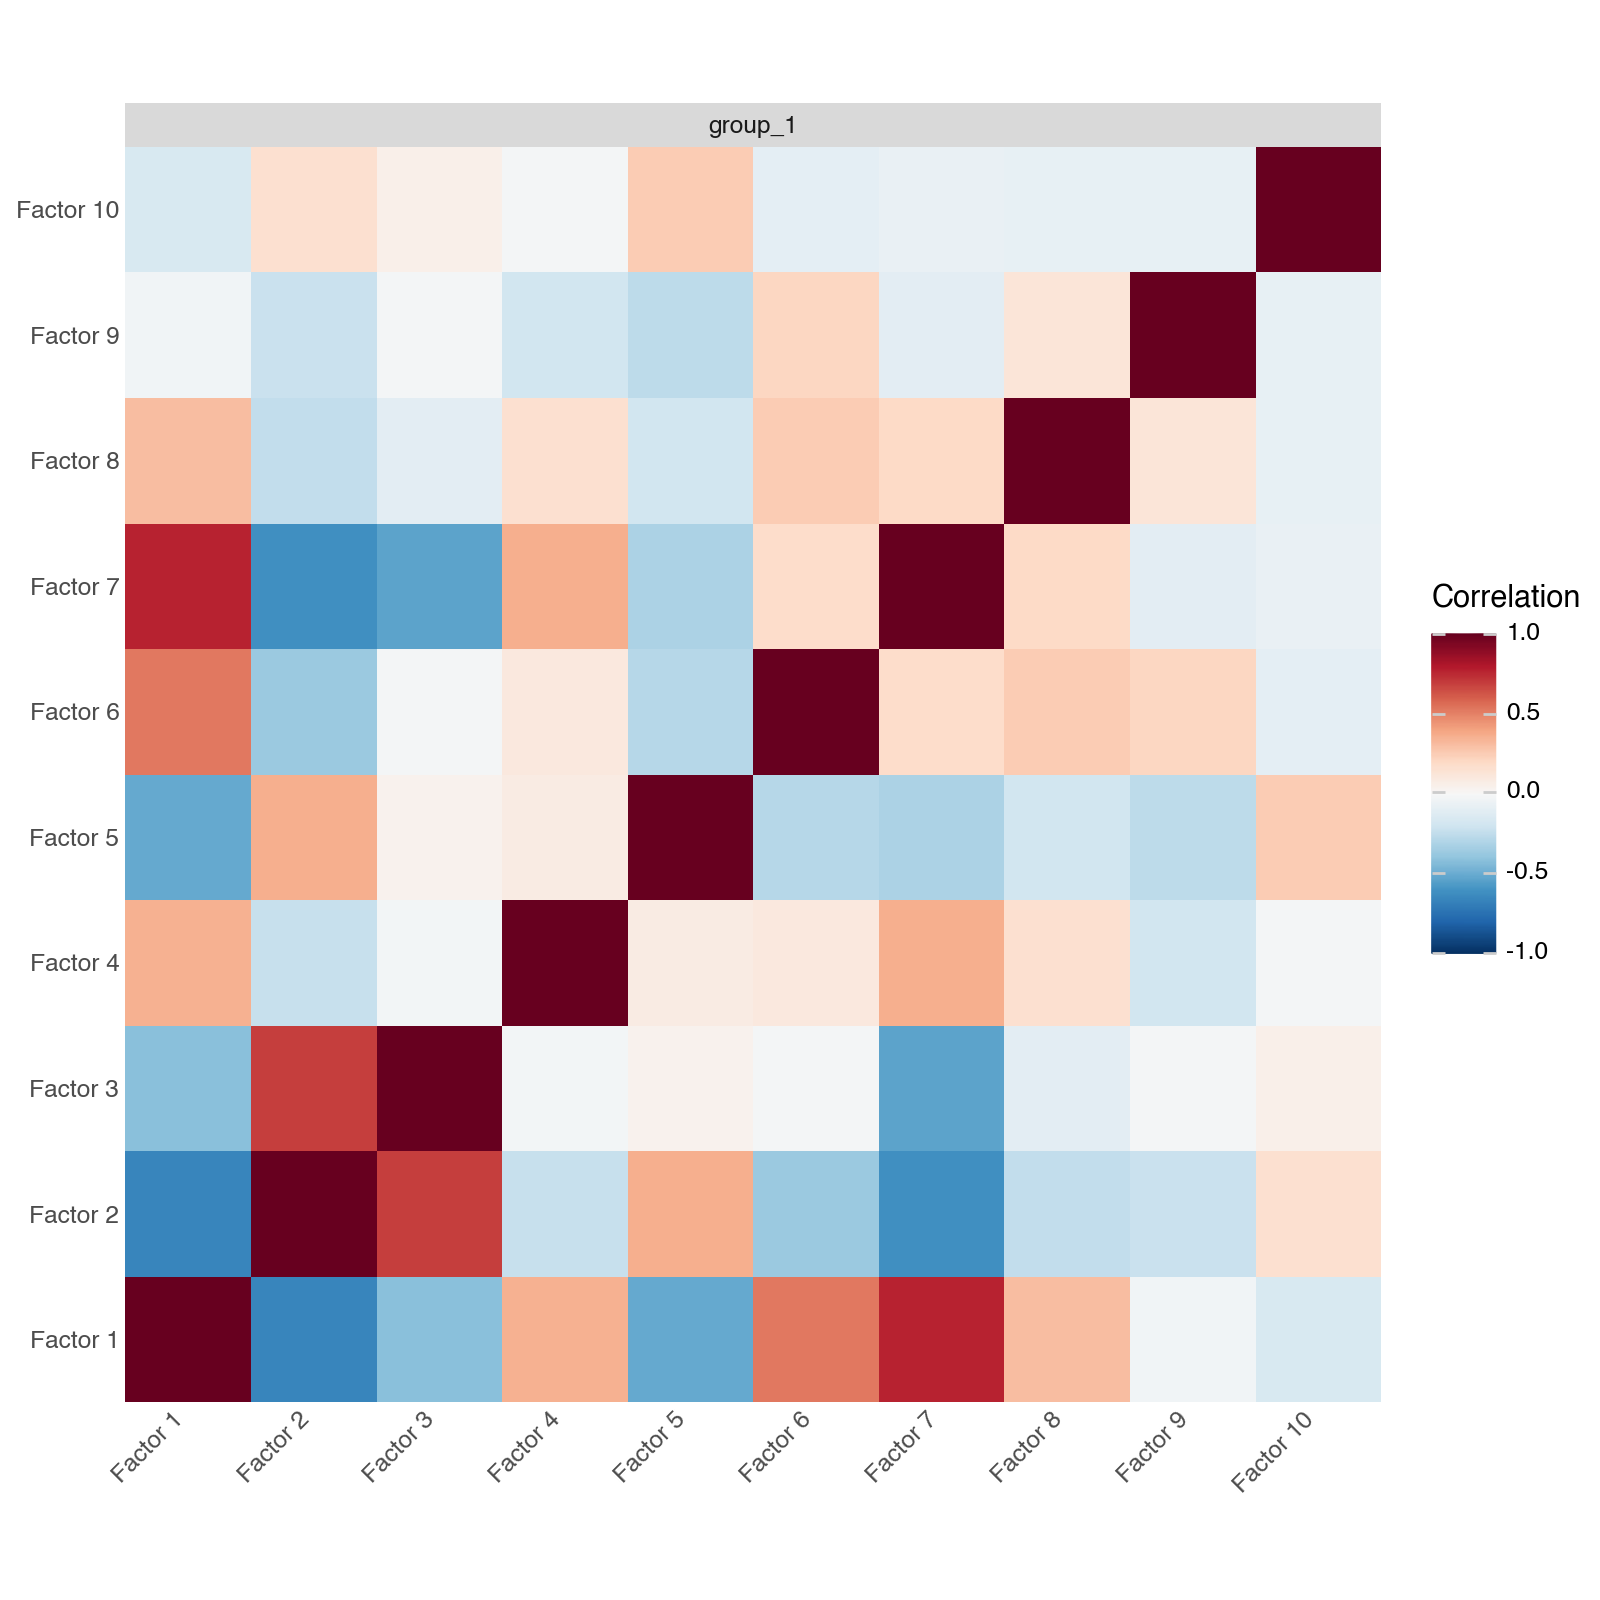

In [ ]:
#Factor correlation
mfl.pl.factor_correlation(model)

In [ ]:
def filter_factors(model, r2_thresh=0.99):
    r2_df = model.get_r2()["group_1"]
    r2_sorted = r2_df.sum(axis=1).sort_values(ascending=False)

    if r2_thresh < 1.0:
        r2_thresh = (r2_sorted.cumsum() / r2_sorted.sum() < r2_thresh).sum() + 1

    return r2_sorted.iloc[: int(r2_thresh)].index

In [ ]:
factor_adata = model.get_factors("anndata")["group_1"][:, filter_factors(model)]

In [ ]:
factor_adata

View of AnnData object with n_obs × n_vars = 4113 × 10
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'

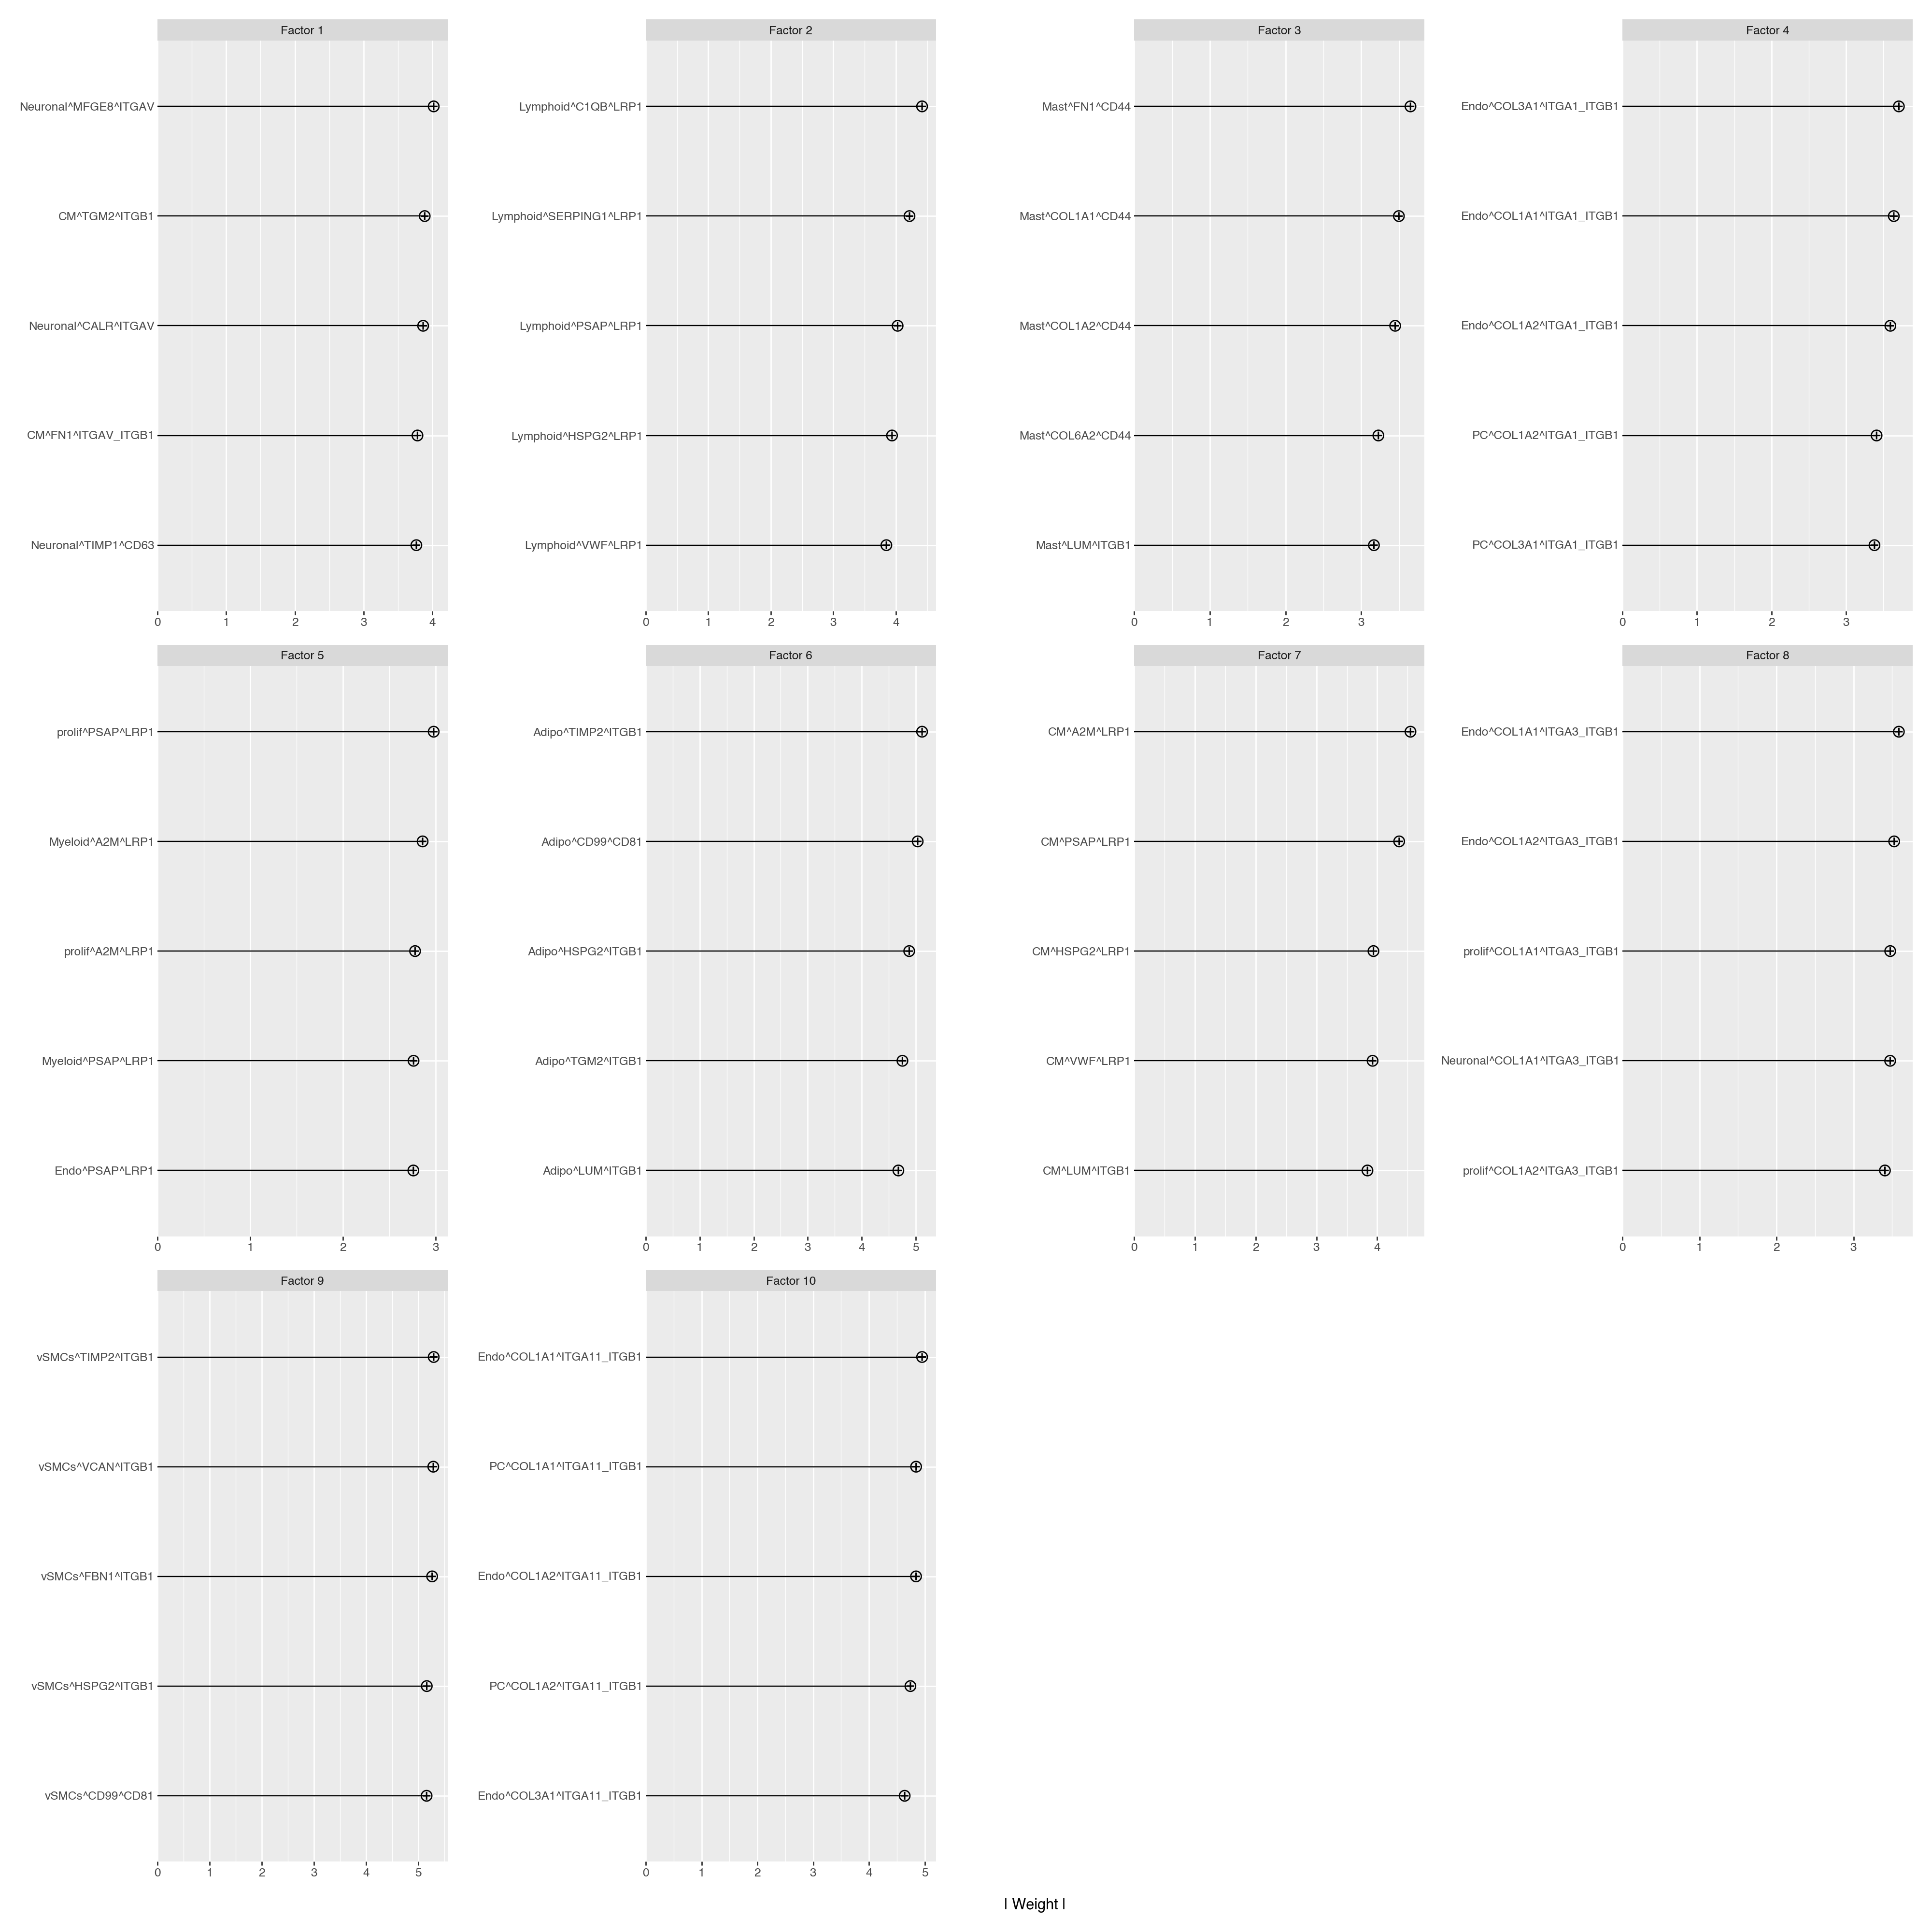

In [ ]:
mfl.pl.top_weights(model, n_features=5, factors=None, figsize=(20, 20), nrow=None, ncol=None)

In [ ]:
mdata.obsm['X_MOFA'] = factor_adata.X

In [ ]:
mdata.obsm['X_MOFA']

ArrayView([[0.6599003 , 0.4295992 , 0.22666737, ..., 0.        ,
            0.69291407, 0.        ],
           [0.        , 0.68754005, 0.05021614, ..., 0.22424525,
            0.3999178 , 0.47532883],
           [0.        , 0.76653683, 0.        , ..., 0.0979083 ,
            0.58111876, 0.        ],
           ...,
           [0.        , 0.64210886, 0.3291272 , ..., 0.11362588,
            0.        , 0.        ],
           [0.        , 0.26156306, 0.13887621, ..., 0.07338601,
            0.        , 0.        ],
           [0.        , 1.0781351 , 0.17330588, ..., 0.66130483,
            0.75597084, 0.        ]], shape=(4113, 10), dtype=float32)

In [ ]:
sc.pp.neighbors(factor_adata, use_rep='X')

In [ ]:
factor_adata

AnnData object with n_obs × n_vars = 4113 × 10
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
    uns: 'neighbors'
    obsp: 'distances', 'connectivities'

In [ ]:
sc.tl.umap(factor_adata, neighbors_key='neighbors')

... storing 'in_tissue' as categorical
... storing 'array_row' as categorical
... storing 'array_col' as categorical
... storing 'sample' as categorical
... storing 'n_genes_by_counts' as categorical
... storing 'log1p_n_genes_by_counts' as categorical
... storing 'total_counts' as categorical
... storing 'log1p_total_counts' as categorical
... storing 'pct_counts_in_top_50_genes' as categorical
... storing 'pct_counts_in_top_100_genes' as categorical
... storing 'pct_counts_in_top_200_genes' as categorical
... storing 'pct_counts_in_top_500_genes' as categorical
... storing 'mt_frac' as categorical
... storing 'celltype_niche' as categorical
... storing 'molecular_niche' as categorical
... storing 'cell_type' as categorical


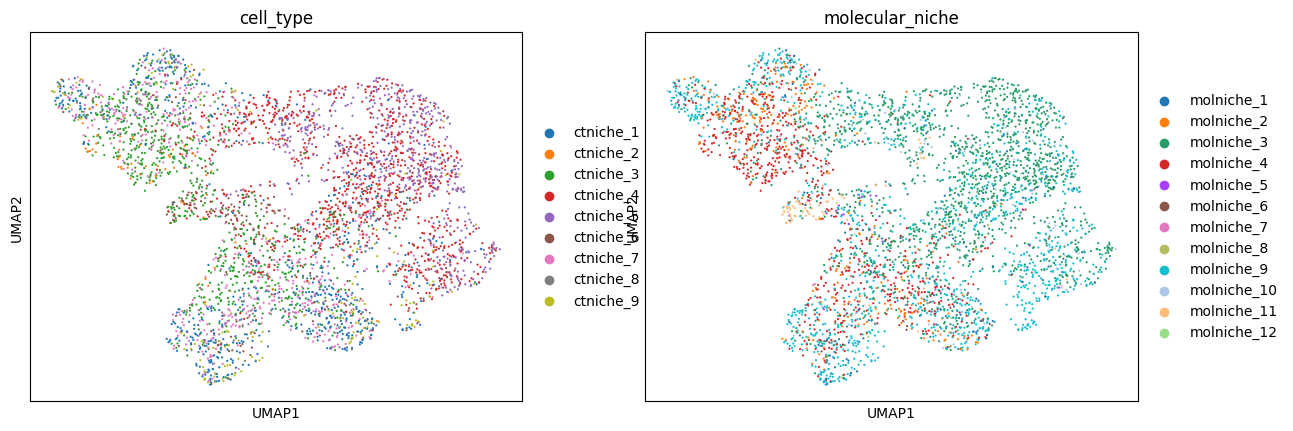

In [ ]:
sc.pl.umap(
    factor_adata,
    color=["cell_type", "molecular_niche"],
    # Setting a smaller point size to get prevent overlap
    size=10,
)

In [ ]:
sc.tl.leiden(factor_adata, resolution=0.5)

/var/folders/gk/kmrvz5m90sb9wftqk2n94p0h0000gq/T/ipykernel_15954/420081657.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.


In [ ]:
factor_adata.obsm['spatial'] = mdata.obsm['spatial']

/var/folders/gk/kmrvz5m90sb9wftqk2n94p0h0000gq/T/ipykernel_15954/4005847817.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.


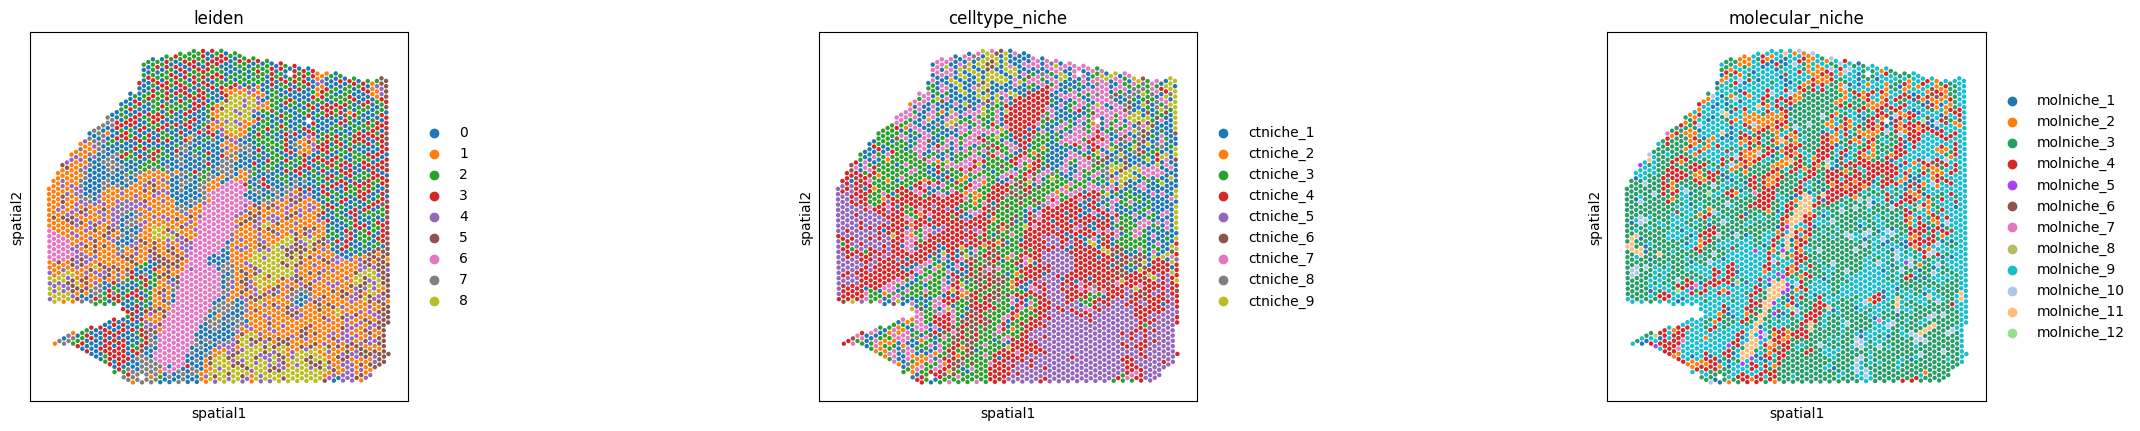

In [ ]:
sc.pl.spatial(factor_adata, basis="spatial", color=["leiden", "celltype_niche", "molecular_niche"], wspace=0.4, spot_size=100)

/Users/b260-admin/miniforge3/envs/liana313/lib/python3.13/site-packages/scanpy/preprocessing/_pca/__init__.py:385: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.


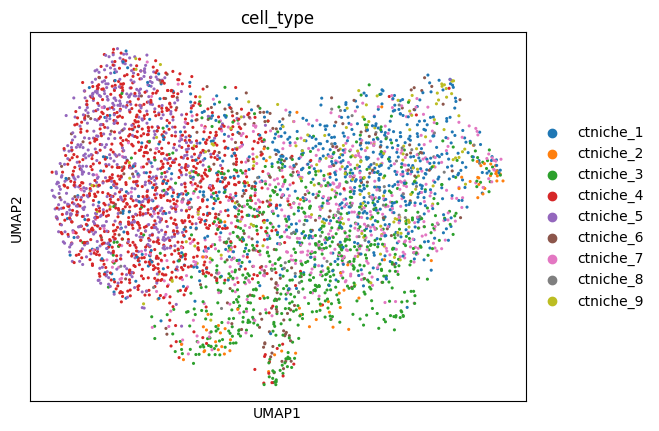

In [ ]:
sc.pp.pca(lrdata)
sc.pp.neighbors(lrdata, use_rep='X_pca')
sc.tl.umap(lrdata, neighbors_key='neighbors')
sc.pl.umap(
    lrdata,
    color=["cell_type"],
    # Setting a smaller point size to get prevent overlap
    size=20,
)